In [1]:
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("NetworkX version:", nx.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Pandas version:", pd.__version__)

NetworkX version: 3.5
Matplotlib version: 3.10.7
Pandas version: 2.3.3


In [2]:
taxonomy = pd.read_csv('taxonomy.csv', encoding='latin1')
print("Taxonomy Dataset Shape:", taxonomy.shape)
print("\nColumns:", list(taxonomy.columns))
print("\nFirst 5 rows:")
print(taxonomy.head())

Taxonomy Dataset Shape: (960, 8)

Columns: ['Unnamed: 0', 'Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Scientific.Name']

First 5 rows:
   Unnamed: 0   Kingdom    Phylum     Class            Order           Family  \
0           1  Animalia  Chordata  Mammalia    Tubulidentata  Orycteropodidae   
1           2  Animalia  Chordata  Mammalia        Carnivora          Felidae   
2           3  Animalia  Chordata  Mammalia     Artiodactyla          Bovidae   
3           4  Animalia  Chordata      Aves  Sphenisciformes     Spheniscidae   
4           5  Animalia  Chordata  Mammalia        Carnivora          Canidae   

         Genus      Scientific.Name  
0  Orycteropus     Orycteropus afer  
1        Felis          Felis catus  
2        Addax  Addax nasomaculatus  
3   Pygoscelis   Pygoscelis adeliae  
4        Canis          Canis Lupus  


In [3]:
print("=== Taxonomy Dataset Summary ===")
print(f"Total species     : {len(taxonomy)}")
print(f"Kingdoms          : {taxonomy['Kingdom'].unique()}")
print(f"Unique Phyla      : {taxonomy['Phylum'].nunique()}")
print(f"Unique Classes    : {taxonomy['Class'].nunique()}")
print(f"Unique Orders     : {taxonomy['Order'].nunique()}")
print(f"Unique Families   : {taxonomy['Family'].nunique()}")
print(f"Unique Genera     : {taxonomy['Genus'].nunique()}")

=== Taxonomy Dataset Summary ===
Total species     : 960
Kingdoms          : ['Animalia']
Unique Phyla      : 6
Unique Classes    : 16
Unique Orders     : 112
Unique Families   : 248
Unique Genera     : 424


In [4]:
facebook = pd.read_csv('musae_facebook_edges.csv', encoding='latin1')
print("Facebook Dataset Shape:", facebook.shape)
print("\nColumns:", list(facebook.columns))
print("\nFirst 5 rows:")
print(facebook.head())

Facebook Dataset Shape: (171002, 2)

Columns: ['id_1', 'id_2']

First 5 rows:
   id_1   id_2
0     0  18427
1     1  21708
2     1  22208
3     1  22171
4     1   6829


In [5]:
all_nodes = set(facebook['id_1']).union(set(facebook['id_2']))
print("=== Facebook Page-Page Network Summary ===")
print(f"Total edges (connections)          : {len(facebook):,}")
print(f"Total unique nodes (pages)         : {len(all_nodes):,}")
print(f"Average degree (connections/page)  : {(2 * len(facebook)) / len(all_nodes):.2f}")

=== Facebook Page-Page Network Summary ===
Total edges (connections)          : 171,002
Total unique nodes (pages)         : 22,470
Average degree (connections/page)  : 15.22


In [6]:
G_tree = nx.DiGraph()

tree_data = taxonomy[['Kingdom', 'Phylum', 'Class']].drop_duplicates()
for _, row in tree_data.iterrows():
    G_tree.add_edge(str(row['Kingdom']), str(row['Phylum']))
    G_tree.add_edge(str(row['Phylum']), str(row['Class']))

print(f"Tree Nodes  : {G_tree.number_of_nodes()}")
print(f"Tree Edges  : {G_tree.number_of_edges()}")
print(f"Is DAG      : {nx.is_directed_acyclic_graph(G_tree)}")

node_colors_tree = {}
for n in G_tree.nodes():
    if n in taxonomy['Kingdom'].values:
        node_colors_tree[n] = '#E74C3C'
    elif n in taxonomy['Phylum'].values:
        node_colors_tree[n] = '#3498DB'
    else:
        node_colors_tree[n] = '#2ECC71'

legend_handles = [
    mpatches.Patch(color='#E74C3C', label='Kingdom'),
    mpatches.Patch(color='#3498DB', label='Phylum'),
    mpatches.Patch(color='#2ECC71', label='Class')
]

node_color_list = [node_colors_tree.get(n, '#95A5A6') for n in G_tree.nodes()]

Tree Nodes  : 23
Tree Edges  : 24
Is DAG      : True


In [7]:
def hierarchy_pos(G, width=2.0, vert_gap=0.35):
    roots = [n for n, d in G.in_degree() if d == 0]
    root = roots[0]

    def _pos(G, node, left, right, vert_loc, pos):
        children = list(G.successors(node))
        if children:
            dx = (right - left) / len(children)
            nextx = left + dx / 2
            for child in children:
                pos[child] = (nextx, vert_loc - vert_gap)
                _pos(G, child, nextx - dx/2, nextx + dx/2,
                     vert_loc - vert_gap, pos)
                nextx += dx
        return pos

    pos = {root: (width / 2, 0)}
    pos = _pos(G, root, 0, width, 0, pos)
    return pos

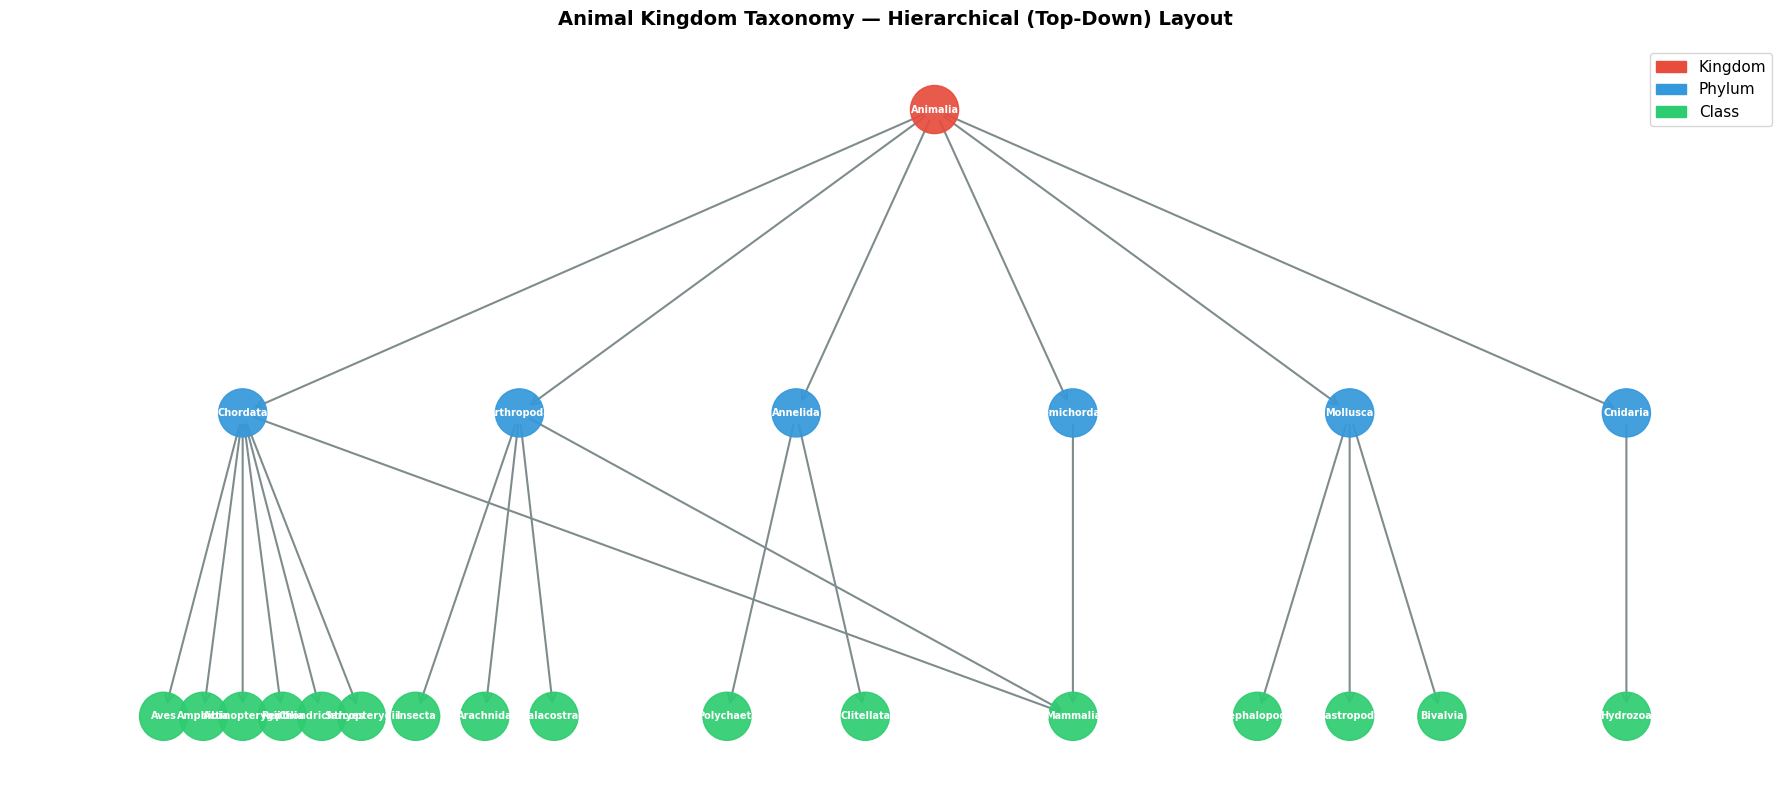

Saved: tree_layout1_hierarchical.png


In [8]:
fig, ax = plt.subplots(figsize=(18, 8))
pos_hier = hierarchy_pos(G_tree)

nx.draw_networkx_nodes(G_tree, pos_hier, node_color=node_color_list,
                       node_size=1200, ax=ax, alpha=0.92)
nx.draw_networkx_edges(G_tree, pos_hier, ax=ax, edge_color='#7F8C8D',
                       arrows=True, arrowstyle='->', arrowsize=15, width=1.5)
nx.draw_networkx_labels(G_tree, pos_hier, ax=ax, font_size=7,
                        font_weight='bold', font_color='white')

ax.legend(handles=legend_handles, loc='upper right', fontsize=11)
ax.set_title('Animal Kingdom Taxonomy — Hierarchical (Top-Down) Layout',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('tree_layout1_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tree_layout1_hierarchical.png")

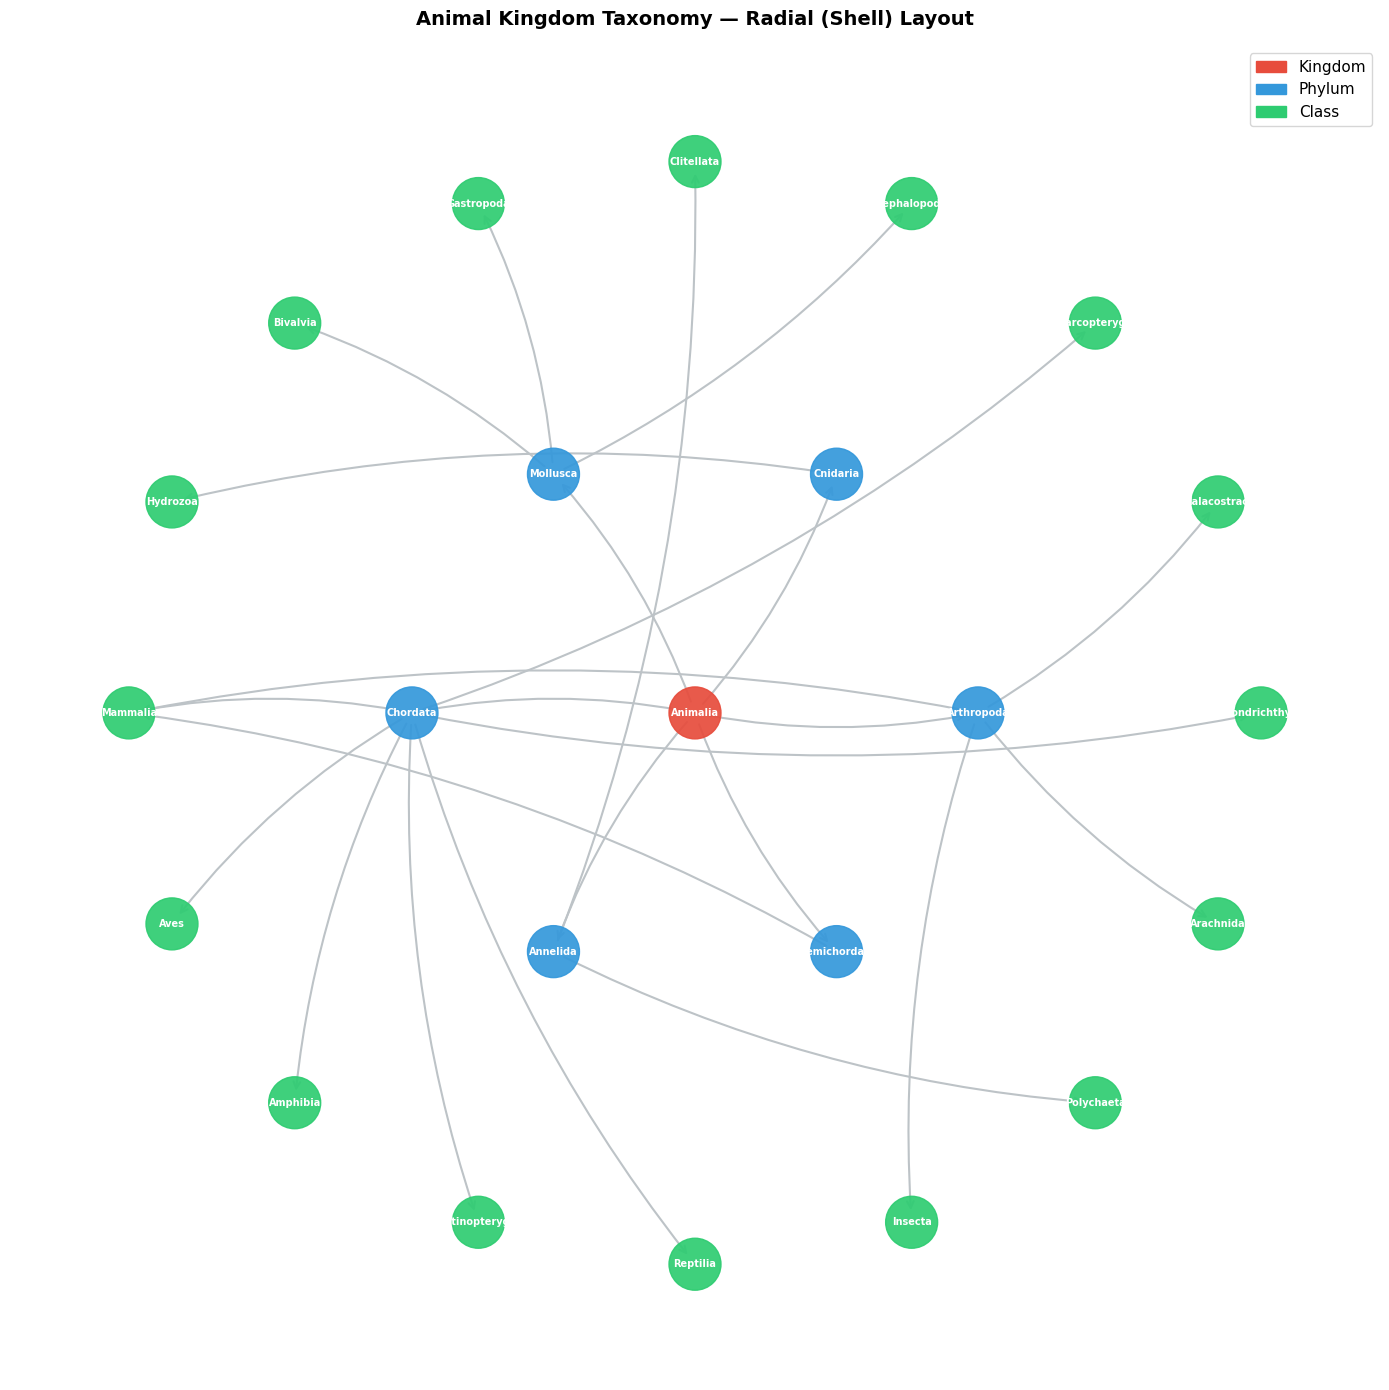

Saved: tree_layout2_radial.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 14))

roots  = [n for n, d in G_tree.in_degree() if d == 0]
level1 = list(set([v for u, v in G_tree.edges() if u in roots]))
level2 = [n for n in G_tree.nodes() if n not in roots and n not in level1]
shells = [roots, level1, level2]

pos_radial = nx.shell_layout(G_tree, nlist=shells)

nx.draw_networkx_nodes(G_tree, pos_radial, node_color=node_color_list,
                       node_size=1400, ax=ax, alpha=0.92)
nx.draw_networkx_edges(G_tree, pos_radial, ax=ax, edge_color='#BDC3C7',
                       arrows=True, arrowstyle='->', arrowsize=12, width=1.5,
                       connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(G_tree, pos_radial, ax=ax, font_size=7,
                        font_weight='bold', font_color='white')

ax.legend(handles=legend_handles, loc='upper right', fontsize=11)
ax.set_title('Animal Kingdom Taxonomy — Radial (Shell) Layout',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('tree_layout2_radial.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tree_layout2_radial.png")

In [10]:
FG_full = nx.from_pandas_edgelist(facebook, 'id_1', 'id_2')
print(f"Full graph — Nodes: {FG_full.number_of_nodes():,}, Edges: {FG_full.number_of_edges():,}")

degrees_sorted = sorted(FG_full.degree(), key=lambda x: x[1], reverse=True)
top_nodes = [n for n, d in degrees_sorted[:80]]
FG = FG_full.subgraph(top_nodes).copy()

print(f"\nSubgraph — Nodes: {FG.number_of_nodes()}, Edges: {FG.number_of_edges()}")
print(f"Top 5 page IDs (most connected): {[n for n, d in degrees_sorted[:5]]}")

degree_vals    = [FG.degree(n) for n in FG.nodes()]
max_d          = max(degree_vals)
node_sizes_fb  = [200 + 1500 * (d / max_d) for d in degree_vals]
node_colors_fb = [plt.cm.plasma(d / max_d) for d in degree_vals]

top5_nodes = [n for n, d in degrees_sorted[:5] if n in FG.nodes()]
labels_fb  = {n: f'ID:{n}' for n in top5_nodes}

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma,
                            norm=plt.Normalize(vmin=0, vmax=max_d))
sm.set_array([])

Full graph — Nodes: 22,470, Edges: 171,002

Subgraph — Nodes: 80, Edges: 1069
Top 5 page IDs (most connected): [16895, 19743, 21729, 14497, 1387]


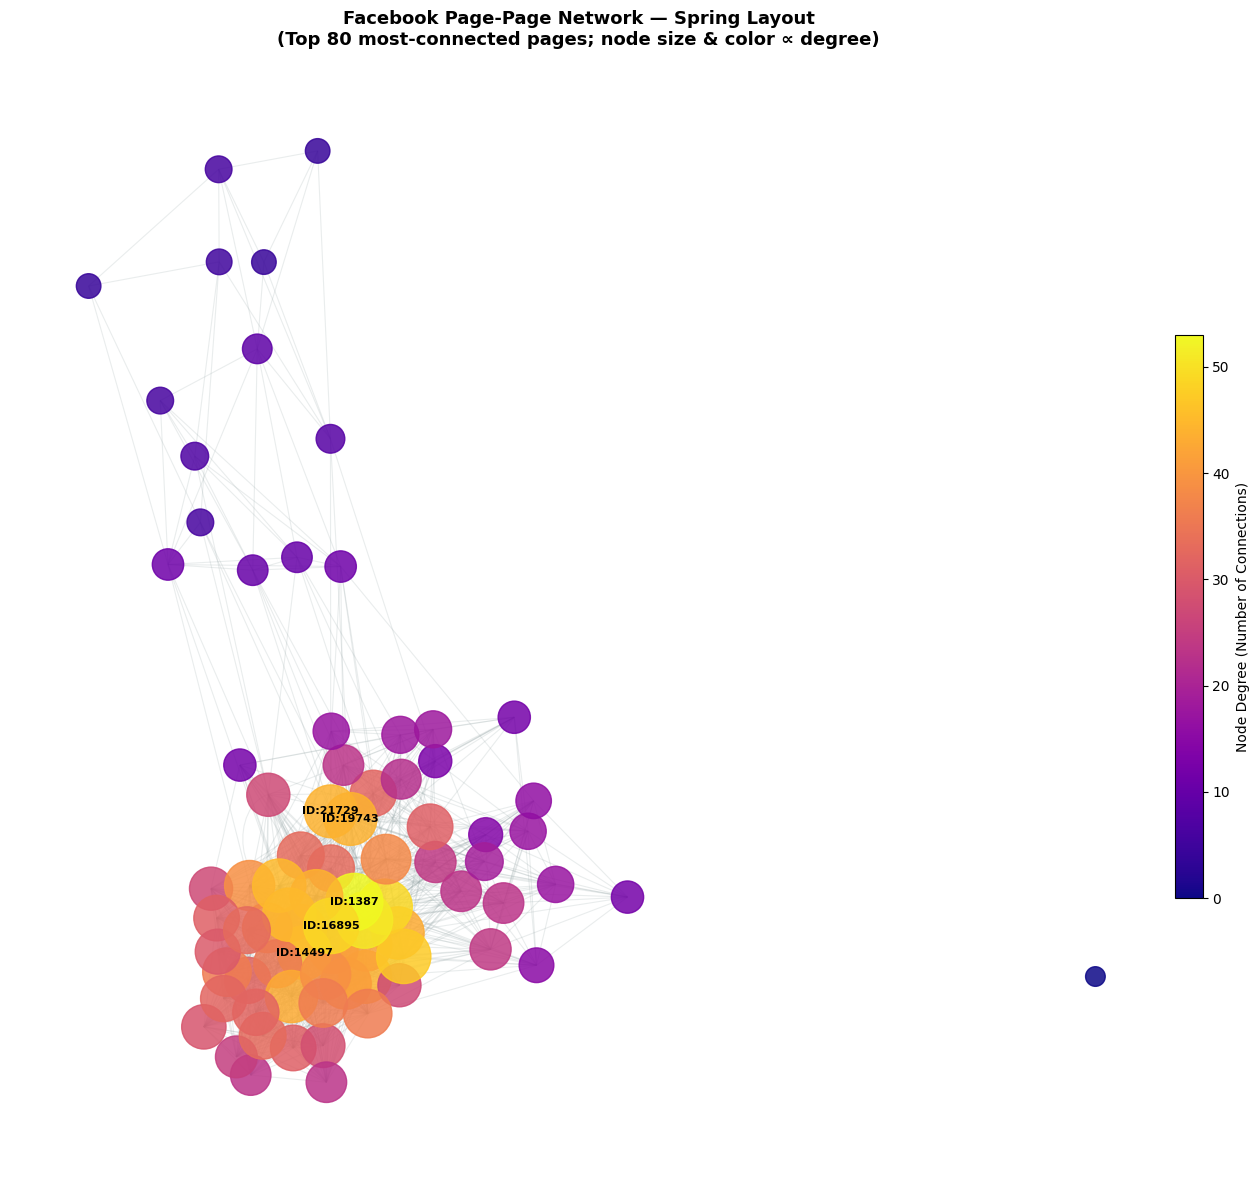

Saved: graph_layout3_spring.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 12))
pos_spring = nx.spring_layout(FG, seed=42, k=0.4)

nx.draw_networkx_edges(FG, pos_spring, ax=ax,
                       alpha=0.2, edge_color='#95A5A6', width=0.8)
nx.draw_networkx_nodes(FG, pos_spring, node_color=node_colors_fb,
                       node_size=node_sizes_fb, ax=ax, alpha=0.85)
nx.draw_networkx_labels(FG, pos_spring, labels=labels_fb,
                        ax=ax, font_size=8, font_weight='bold')

ax.set_title('Facebook Page-Page Network — Spring Layout\n'
             '(Top 80 most-connected pages; node size & color ∝ degree)',
             fontsize=13, fontweight='bold')
ax.axis('off')
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Node Degree (Number of Connections)', fontsize=10)
plt.tight_layout()
plt.savefig('graph_layout3_spring.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graph_layout3_spring.png")

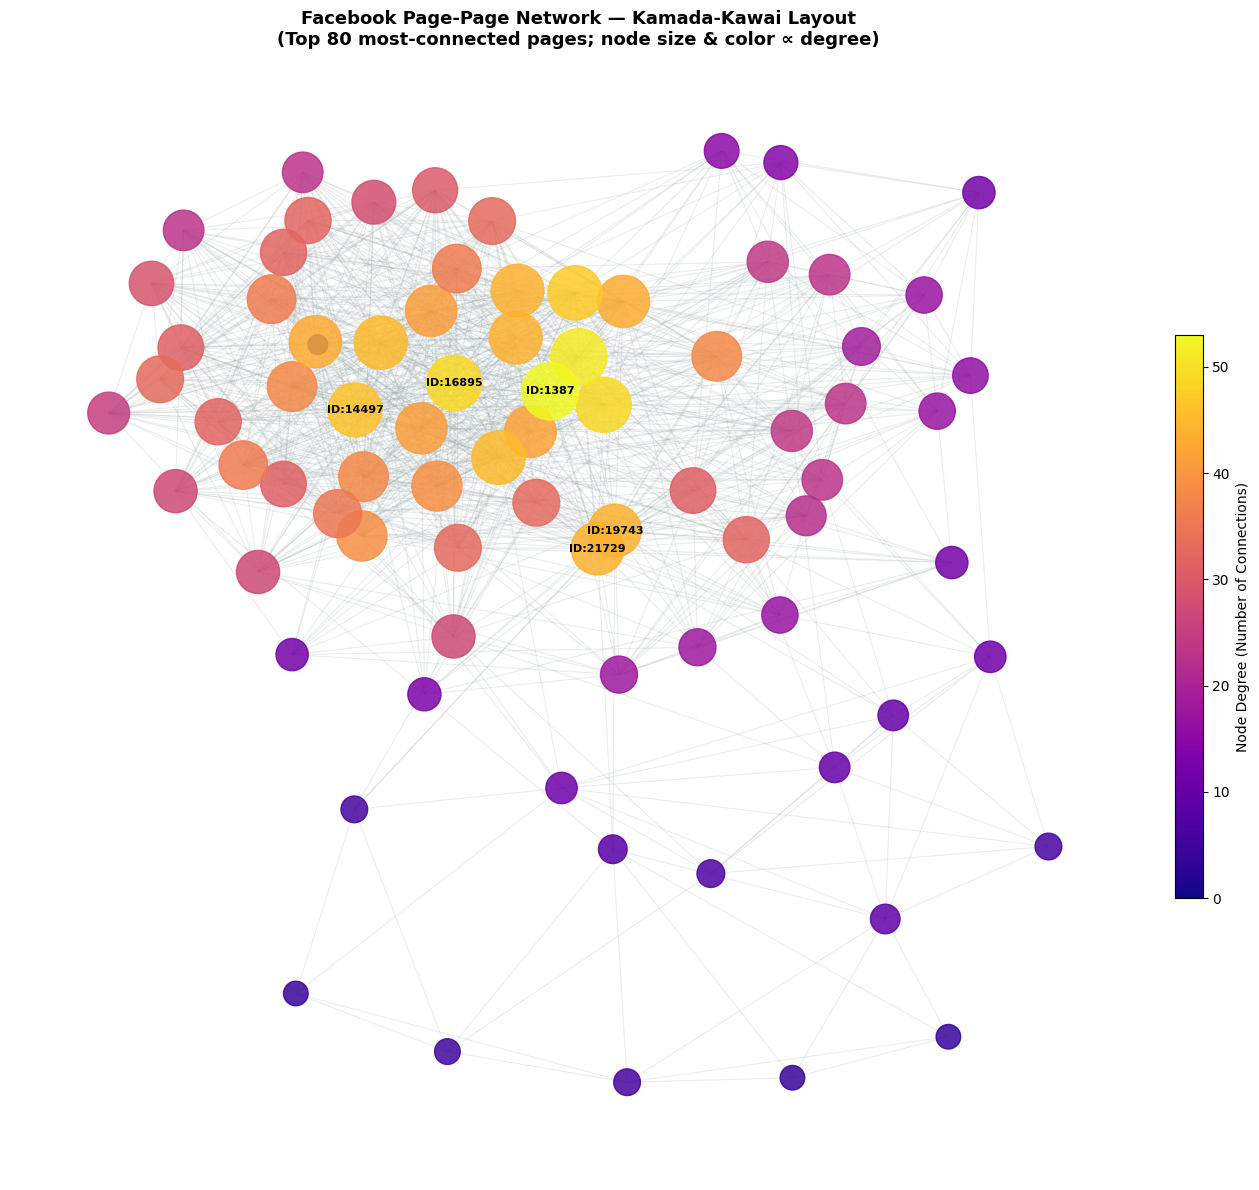

Saved: graph_layout4_kamada.png

All 4 visualizations complete!


In [12]:
fig, ax = plt.subplots(figsize=(14, 12))
pos_kk = nx.kamada_kawai_layout(FG)

nx.draw_networkx_edges(FG, pos_kk, ax=ax,
                       alpha=0.2, edge_color='#95A5A6', width=0.8)
nx.draw_networkx_nodes(FG, pos_kk, node_color=node_colors_fb,
                       node_size=node_sizes_fb, ax=ax, alpha=0.85)
nx.draw_networkx_labels(FG, pos_kk, labels=labels_fb,
                        ax=ax, font_size=8, font_weight='bold')

ax.set_title('Facebook Page-Page Network — Kamada-Kawai Layout\n'
             '(Top 80 most-connected pages; node size & color ∝ degree)',
             fontsize=13, fontweight='bold')
ax.axis('off')
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Node Degree (Number of Connections)', fontsize=10)
plt.tight_layout()
plt.savefig('graph_layout4_kamada.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graph_layout4_kamada.png")
print("\nAll 4 visualizations complete!")